## **AI and Machine Learning Part B (Regression)**

<b>Name:</b> Khambhati Moiz Huzefa

<b>Class:</b> DAAA/FT/1B/01

<b>Admin No:</b> P2508625

<br>

### **Background Information**

This assignment uses the **`housing_price_data.csv`** dataset, which was collected from various housing markets across the United States. The dataset includes multiple property-related attributes such as **region**, **city**, **house area**, **number of bedrooms and toilets**, **stories**, and **renovation status**.

From a **real estate analysis** perspective, the objective is to build a **machine learning model** that can predict the **sale price of a house** based on these attributes. This regression task supports **property valuation and investment decisions**, helping stakeholders estimate market prices accurately and identify key factors that influence housing costs.

---


<br>

### **Objectives for This Assignment**

The primary objective of this assignment is to apply the full **machine learning workflow** to a real-world **regression task** that predicts the sale price of houses based on their features.
This project demonstrates the ability to preprocess data, engineer meaningful features, train and evaluate regression models, and fine-tune their performance for accurate price prediction.

#### **Specific Objectives**

* Use **pandas** and **NumPy** for efficient data loading, cleaning, and transformation.
* Conduct **Exploratory Data Analysis (EDA)** to identify patterns, outliers, and relationships between features such as house size, number of rooms, and renovation status.
* Perform **data preprocessing** and **feature engineering**, including encoding categorical variables and creating derived ratios or interactions that better represent property characteristics.
* Develop and compare multiple regression algorithms, including Gradient Boosting Regressor, Random Forest Regressor, Linear Regression, Ridge, Lasso, and ElasticNet, to identify the most effective model for predicting housing prices.
* Apply **hyperparameter tuning** using **GridSearchCV** to optimize model parameters for better predictive accuracy.
* Evaluate model performance using regression metrics including **Mean Absolute Error (MAE)** and **R² score**, ensuring models are both accurate and generalizable.
* Visualize model performance and feature importance using **Seaborn** and **Matplotlib** to support interpretability and insights.
* Reflect on how **data preprocessing**, **feature engineering**, and **hyperparameter tuning** influence model accuracy and robustness.

Ultimately, the goal is to build a **high-performing regression model** capable of accurately estimating housing prices, demonstrating a strong understanding of the complete **machine learning pipeline** from raw data to refined prediction.

---


<br>

### **Importing the libraries required**

In [165]:
# Data Processing 
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline

# Models 
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor

# Evaluation 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Visualisation 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

<br>

### **Data Understanding**

The dataset used in this study, *housing_price_data.csv*, contains information on residential properties across various U.S. cities. Each record represents a single house and provides details about its **physical attributes**, **location**, and **renovation status**, along with its corresponding **sale price**. The dataset consists of **545 observations** and **8 features**, including both numerical and categorical variables such as *House Area (sqm)*, *No. of Bedrooms*, *Stories*, and *City*.

The main objective of this analysis is to build a **predictive model** that can estimate the **sale price of a house** based on its features. This defines a **regression problem**, where the goal is to predict a **continuous numerical value** — the price of the property. The input features, including *House Area*, *No. of Bedrooms*, *No. of Toilets*, *Stories*, *City*, and *Renovation Status*, collectively influence the model’s price estimation.

The **output variable**, *Price ($)*, represents the **predicted sale price** of the house and serves as the **target variable** for the regression model. A higher predicted price generally reflects properties with larger areas, better renovation status, or more desirable city locations.

Understanding how these features interact allows for identifying which factors most strongly affect housing prices, enabling data-driven insights for **real estate valuation**, **market analysis**, and **investment decision-making**.

---


<br>

### **Data Overview**

The dataset, **housing_price_data**, contains information about residential properties from various cities across the United States. It includes **545 records and 8 attributes**, each describing a specific characteristic of a house or its sale price. The variables are summarized below:

| **Feature Name**      | **Description**                                                                             |
| --------------------- | ------------------------------------------------------------------------------------------- |
| **House ID**          | A unique identifier assigned to each property.                                              |
| **City**              | The city where the property is located (e.g., Chicago, Denver, Seattle, New York).          |
| **House Area (sqm)**  | The total built-up area of the house measured in **square meters (sqm)**.                   |
| **No. of Bedrooms**   | The total number of bedrooms available in the property.                                     |
| **No. of Toilets**    | The total number of toilets available in the property.                                      |
| **Stories**           | The number of floors or levels in the house.                                                |
| **Renovation Status** | Indicates the furnishing condition — **furnished**, **semi-furnished**, or **unfurnished**. |
| **Price ($)**         | The target variable representing the **sale price** of the property in U.S. dollars.        |

The dataset contains a mix of **categorical** variables (*City*, *Renovation Status*) and **numerical** variables (*House Area*, *No. of Bedrooms*, *Stories*, etc.), offering a well-rounded view of the factors that influence property valuation.

This combination of structural and locational features makes the dataset ideal for constructing a **machine learning regression model** that predicts house prices based on physical characteristics, furnishing condition, and location.

---


<br>

### **Explanatory Data Analysis of factory_data.csv Dataset**

In [166]:

# Importing the dataset housing_price_data.csv as df
df = pd.read_csv("datasets/housing_price_data.csv")

print("Shape:",df.shape)
print("\nIndex:",df.index)
print("\nColumns:",df.columns)
print("\nCount of non-missing values:\n",df.count())
print("\nDataFrame Info:\n")
df.info()
print("\nDescriptive Statistics:\n", df.describe())
print("\nData Types: \n", df.dtypes)
print("\nFirst 5 records in DataFrame")
df.head()


Shape: (545, 8)

Index: RangeIndex(start=0, stop=545, step=1)

Columns: Index(['House ID', 'City', 'House Area (sqm)', 'No. of Bedrooms',
       'No. of Toilets', 'Stories', 'Renovation Status', 'Price ($)'],
      dtype='object')

Count of non-missing values:
 House ID             545
City                 545
House Area (sqm)     545
No. of Bedrooms      545
No. of Toilets       545
Stories              545
Renovation Status    545
Price ($)            545
dtype: int64

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Sta

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,0,Chicago,742.0,4,2,3,furnished,1330000
1,1,Denver,896.0,4,4,4,furnished,1225000
2,2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,3,Seattle,750.0,4,2,2,furnished,1221500
4,4,New York,742.0,4,1,2,furnished,1141000


<br>

### **Initial Data Inspection**

The dataset, `housing_price_data.csv`, contains **545 records and 8 columns**, representing property listings with details on location, physical structure, renovation status, and sale price. The index ranges from 0 to 544, with each entry corresponding to an individual house.

#### **Dataset Structure**

The dataset includes both categorical and numerical features:

* **Categorical Columns:** `City`, `Renovation Status`
* **Numerical Columns:** `House ID`, `House Area (sqm)`, `No. of Bedrooms`, `No. of Toilets`, `Stories`, `Price ($)`

From the data types summary, five columns are stored as `int64`, one as `float64`, and two as `object` types. This balanced mix of data types provides opportunities for both **encoding categorical variables** and **scaling numerical ones** during preprocessing.

#### **Missing Values**

All columns are **complete**, with **no missing values** detected. Each of the 545 observations contains full information for every feature, making the dataset clean and ready for exploratory data analysis without requiring imputation.

#### **Descriptive Statistics**

The numerical features exhibit clear and interpretable ranges:

* **House Area (sqm):** Ranges from **165** to **1,620 sqm**, with an average area of approximately **515 sqm**.
* **No. of Bedrooms:** Varies between **1 and 6**, with an average of **3 bedrooms per house**.
* **No. of Toilets:** Typically **1–4**, averaging around **1.3 toilets per house**.
* **Stories:** Houses have between **1 and 4 stories**, with most properties being **1–2 storeys tall**.
* **Price ($):** Sale prices range from **$175,000** to **$1,330,000**, with a mean of around **$476,000**, suggesting a moderate spread in property values across cities.

#### **Initial Observations**

The dataset is **complete, consistent, and well-structured**, containing a balanced variety of features suitable for regression modeling. The spread in *house area* and *price* indicates a healthy range for learning relationships between property characteristics and sale value.

Further analyses — including **distribution visualizations** and a **correlation matrix** — will help identify potential relationships, detect outliers, and highlight which factors most strongly influence housing prices.


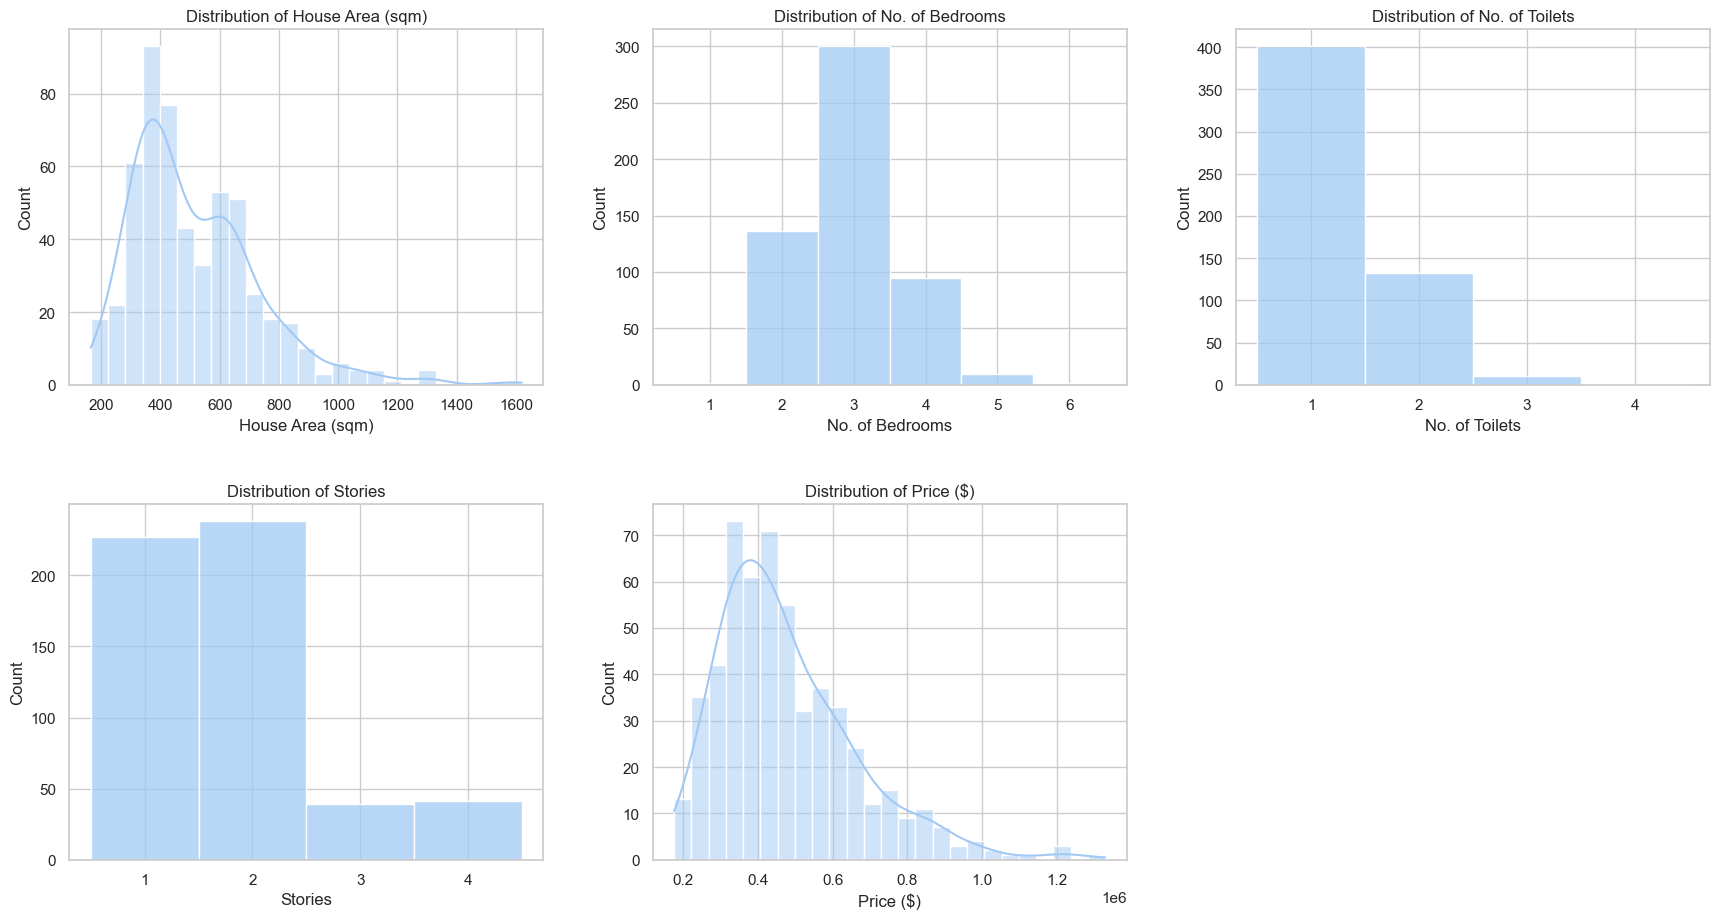

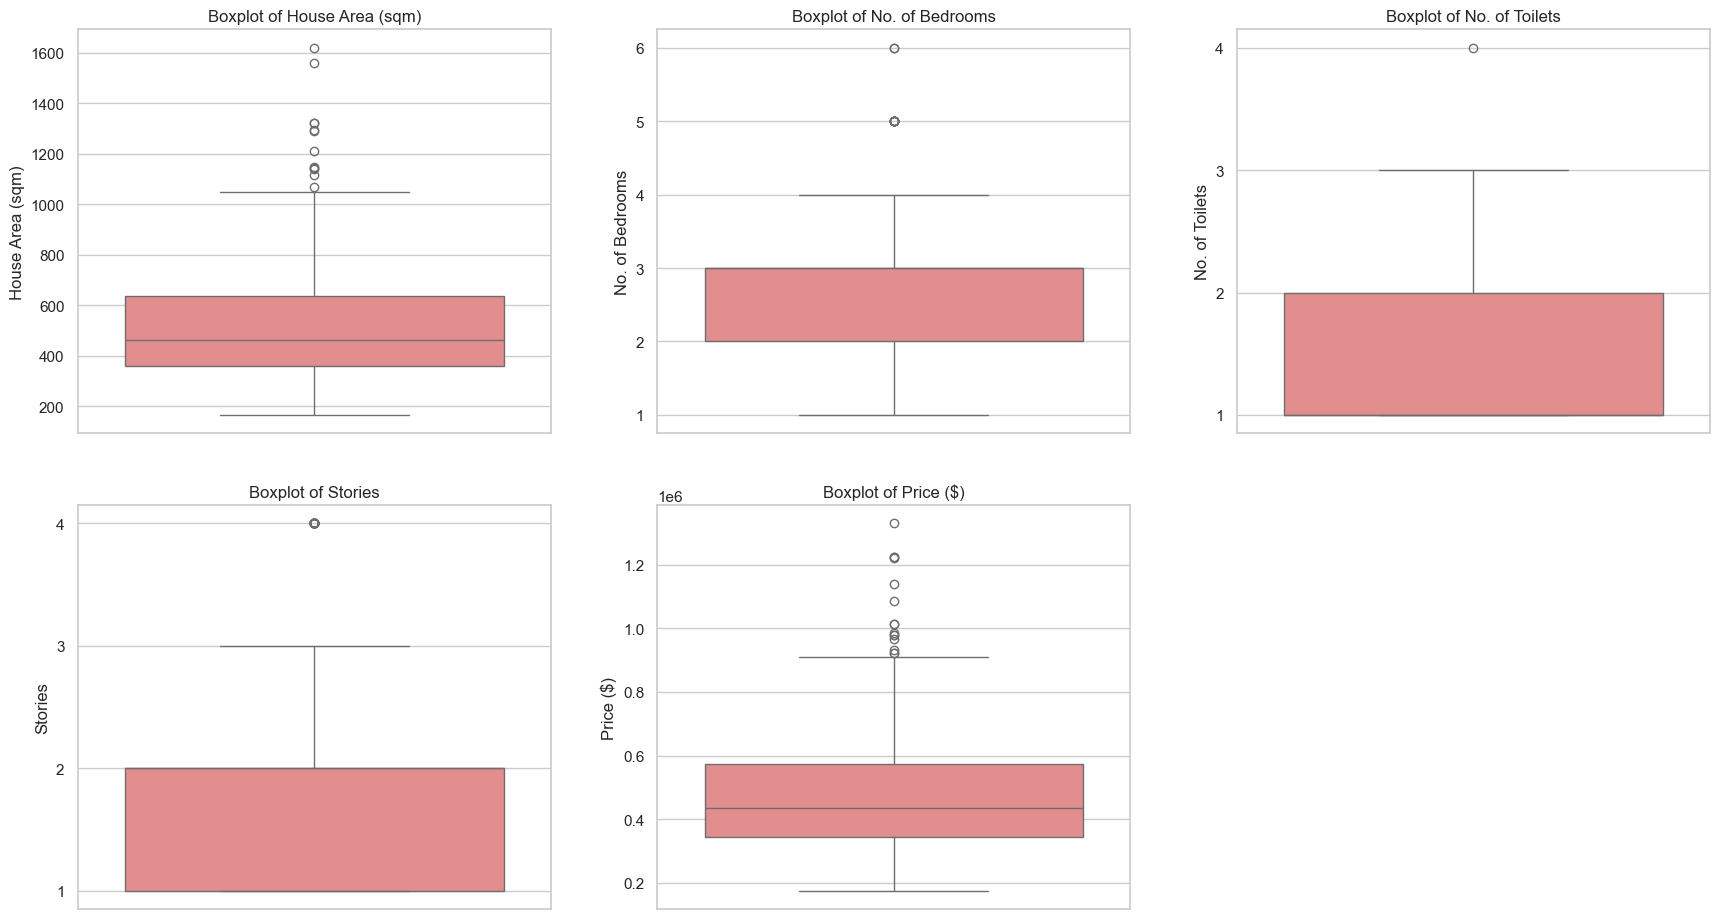

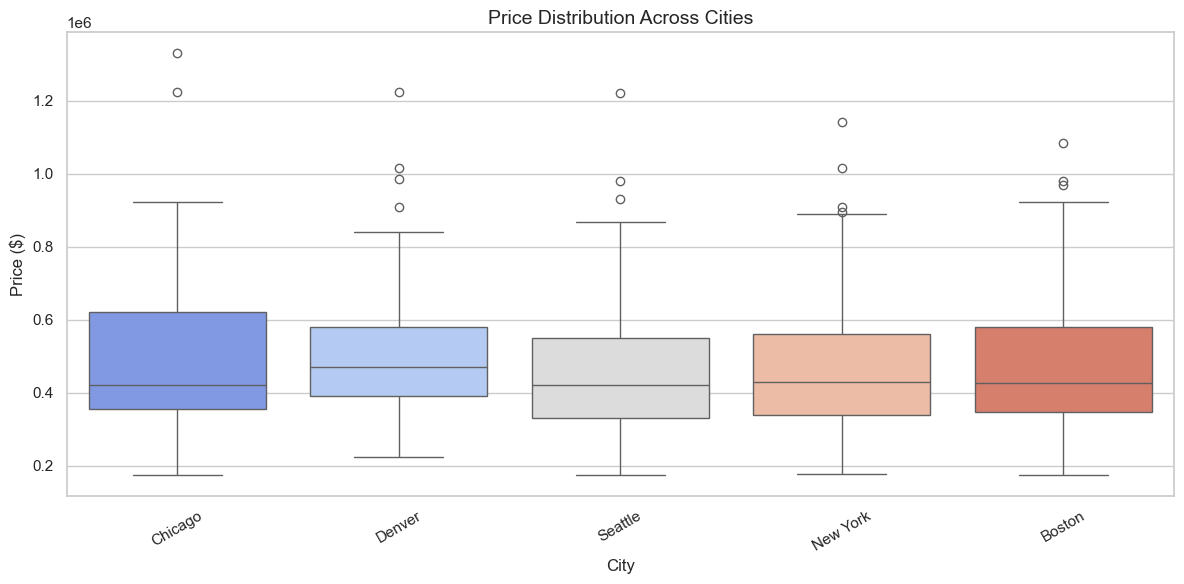

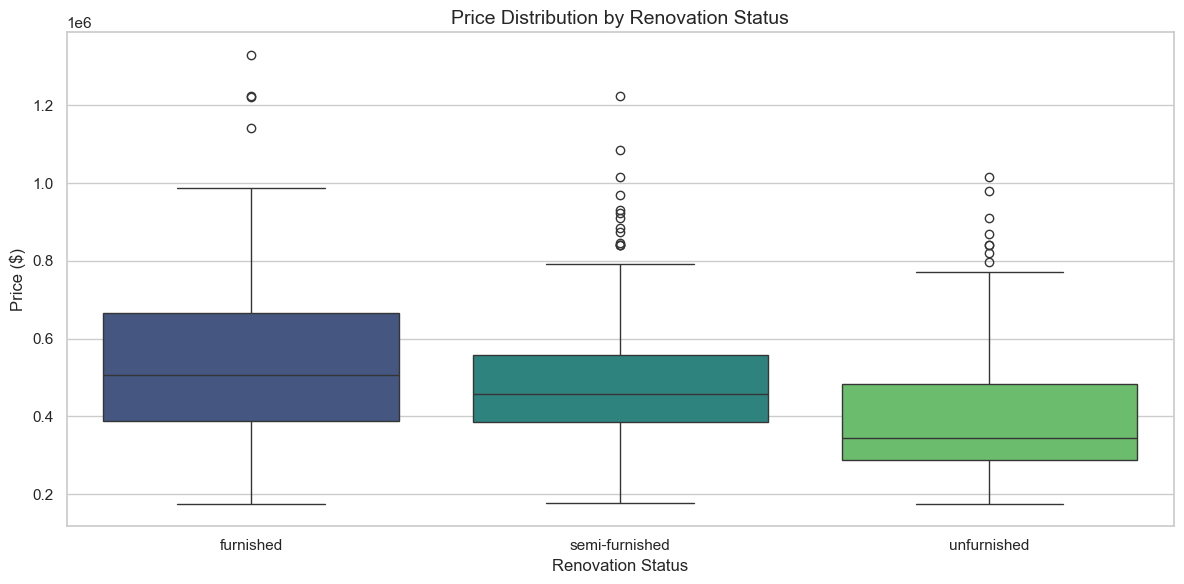

In [167]:
sns.set_theme(style="whitegrid", palette="pastel")

numeric_cols = ["House Area (sqm)", "No. of Bedrooms", "No. of Toilets", "Stories", "Price ($)"]
discrete_cols = ["No. of Bedrooms", "No. of Toilets", "Stories"]


# 1) Bargraph and Histogram of distribution in the columns

plt.figure(figsize=(18, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)

    if col in discrete_cols:
        sns.histplot(df[col], discrete=True, kde=False)
        # Force integer ticks on X-axis
        plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    else:
        sns.histplot(df[col], bins=25, kde=True)

    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout(pad=3.0)
plt.show()


# 2) Boxplots of distribution in the columns

plt.figure(figsize=(18, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)

    sns.boxplot(data=df, y=col, color="lightcoral")

    # Force integer ticks on Y-axis for discrete features
    if col in discrete_cols:
        plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.ylabel(col)

plt.tight_layout(pad=3.0)
plt.show()


# 3) City-wise Price Distribution

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="City",
    y="Price ($)",
    hue="City",
    palette="coolwarm",
    legend=False
)

plt.title("Price Distribution Across Cities", fontsize=14)
plt.xlabel("City")
plt.ylabel("Price ($)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# 4) Renovation Status vs Price

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Renovation Status",
    y="Price ($)",
    hue="Renovation Status",
    palette="viridis",
    legend=False
)

plt.title("Price Distribution by Renovation Status", fontsize=14)
plt.xlabel("Renovation Status")
plt.ylabel("Price ($)")

plt.tight_layout()
plt.show()

Correlation Matrix:
                   House ID  House Area (sqm)  No. of Bedrooms  No. of Toilets  \
House ID          1.000000         -0.541468        -0.371096       -0.467336   
House Area (sqm) -0.541468          1.000000         0.151858        0.193820   
No. of Bedrooms  -0.371096          0.151858         1.000000        0.373930   
No. of Toilets   -0.467336          0.193820         0.373930        1.000000   
Stories          -0.413518          0.083996         0.408564        0.326165   
Price ($)        -0.929878          0.535997         0.366494        0.517545   

                   Stories  Price ($)  
House ID         -0.413518  -0.929878  
House Area (sqm)  0.083996   0.535997  
No. of Bedrooms   0.408564   0.366494  
No. of Toilets    0.326165   0.517545  
Stories           1.000000   0.420712  
Price ($)         0.420712   1.000000  


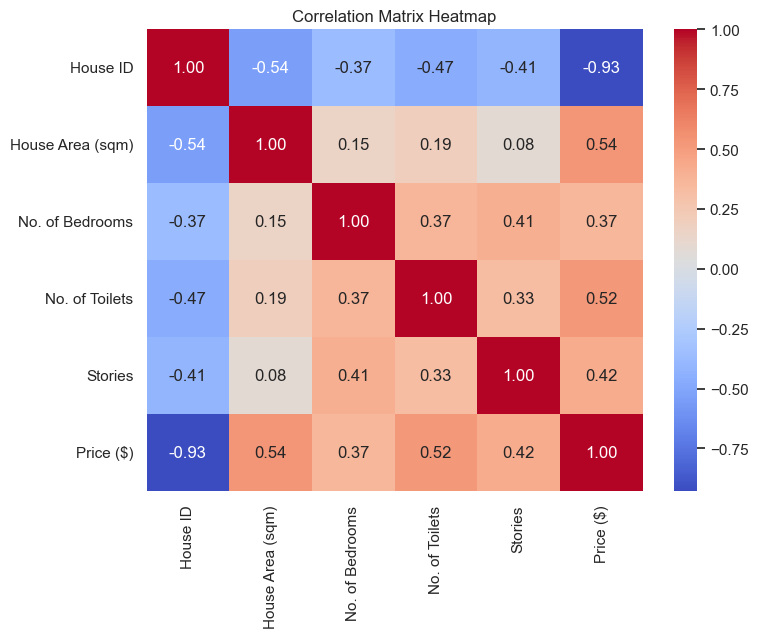

In [168]:
# Compute correlation matrix (only numeric columns)
corr_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
print("Correlation Matrix:\n", corr_matrix)

# Visualize with a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

### **Overall Data Analysis**

#### **1. Distribution Patterns**

The histograms show that several numerical features — particularly `House Area (sqm)` and `Price ($)` — follow right-skewed distributions. This means that:

* Most houses fall within a typical, moderate range.
* A smaller group represents significantly larger or more expensive properties.

Key observations:

* `House Area (sqm)` is concentrated between `300–700 sqm`, with a handful of very large homes above `1000 sqm`.
* `Price ($)` mostly ranges from `$300,000 to $600,000`, with luxury homes surpassing `$1,000,000`.
* `No. of Bedrooms`, `No. of Toilets`, and `Stories` behave as discrete variables.  
  Most homes have:
  * `3` bedrooms  
  * `1` toilet  
  * `1–2` stories  

These patterns suggest a predominantly mid-range housing dataset with occasional premium properties.

#### **2. Outlier Detection**

The boxplots reveal several meaningful outliers:

* `House Area (sqm)` and `Price ($)` contain extreme values, indicating upscale or luxury houses in the dataset.
* Occasional outliers appear in `No. of Bedrooms`, `No. of Toilets`, and `Stories` (e.g., homes with `5–6` bedrooms or `4` toilets).

These outliers:

* Reflect true variability in the housing market  
* May influence regression-based models  
* Could benefit from techniques like log transformation or winsorization

#### **3. City-Wise Comparison**

Price distributions across cities show:

* Median prices are fairly similar across `Chicago`, `Denver`, `Seattle`, `New York`, and `Boston`.
* `Boston` and `New York` trend slightly higher in median and upper ranges.
* All cities contain high-priced outliers, suggesting premium properties exist in every market.

This indicates balanced pricing patterns across locations.

#### **4. Renovation Status and Price**

A clear pricing gradient appears across renovation types:

* `furnished` properties have the highest median prices.
* `semi-furnished` properties follow.
* `unfurnished` homes consistently show the lowest prices.

Since renovation enhances perceived value, `Renovation Status` is likely a strong predictive feature.

#### **5. Correlation Insights**

From the correlation heatmap:

* `House Area (sqm)` shows the strongest positive correlation with `Price ($)` at approximately `0.54`.
* `No. of Toilets`, `No. of Bedrooms`, and `Stories` also correlate positively with price (`0.37–0.52`).
* `House ID` has a strong negative correlation with price (`-0.93`), confirming it is non-informative and should be removed before modeling.

This correlation structure highlights the importance of size-related attributes in predicting housing prices.

#### **Key Takeaways**

* The dataset is clean, complete, and reflects realistic U.S. housing characteristics.
* `House Area (sqm)`, `Renovation Status`, `Stories`, and `No. of Toilets` are likely the most influential predictors of `Price ($)`.
* Right-skewed features and high-end outliers suggest applying log transformations to `Price ($)` and `House Area (sqm)` to improve model performance.
* With no missing data and clear variable behavior, the dataset is well-prepared for regression or machine-learning modeling.

---

<br>

### **Data Preprocessing and Feature Engineering**

#### **1. Drop Irrelevant Columns**

The column **`House ID`** was removed as it does not provide any predictive information and could distort correlation patterns if retained.

#### **2. Encode Categorical Variables**

Categorical features such as **`City`** and **`Renovation Status`** were transformed using a combination of **Dummy Encoding** and **Label Encoding**, enabling the regression model to effectively interpret non-numerical attributes.

#### **3. Create New Features**

Additional features were engineered from variables with strong influence on price, like **House Area**, to enhance the model’s predictive power.

#### **4. Separate Features and Target**

The dataset was divided into **Features (`X`)** and the **Target Variable (`Price ($)`)** to prepare for supervised regression modeling.

#### **5. Train–Test Split**

The dataset was split into **80% training** and **20% testing** subsets to ensure model evaluation accurately reflects performance on unseen data.

#### **6. Feature Scaling**

All **numerical features** were scaled using the **MinMaxScaler** to a uniform range between 0 and 1.
Scaling prevents features with larger magnitudes (e.g., `House Area`) from overpowering those with smaller values.
The scaler was **fitted only on the training data** and later applied to the test set to prevent data leakage. The target variable **`Price ($)`** was excluded from scaling as it represents the continuous value being predicted.




In [169]:
# 1. Drop irrelevant columns
df = df.drop(['House ID'], axis=1)

# 2. Encode categorical variables
# Dummy encode 'City' and label encode 'Renovation Status'
df = pd.get_dummies(df, columns=['City'], drop_first=True)

dummy_cols = [col for col in df.columns if col.startswith("City_")]
df[dummy_cols] = df[dummy_cols].astype(int)

label_encoder = LabelEncoder()
df['Renovation Status'] = label_encoder.fit_transform(df['Renovation Status'].astype(str))

# 3. Feature Engineering
df["Toilets/Bedroom"] = df["No. of Toilets"] / df["No. of Bedrooms"]
df["log_Area"] = np.log1p(df["House Area (sqm)"]) # -> 
df["Area_per_Bedroom"] = df["House Area (sqm)"] / df["No. of Bedrooms"]
df["Size_Score"] = df["House Area (sqm)"] * df["Stories"]
df["Bed_Toilet_Balance"] = df["No. of Bedrooms"] / df["No. of Toilets"] 
df["Total_Rooms"] = df["No. of Bedrooms"] + df["No. of Toilets"]
df["Stories_Bedrooms"] = df["Stories"] * df["No. of Bedrooms"]

# 4. Separate features and target variable
X = df.drop('Price ($)', axis=1)  # Features 
y = np.log1p(df["Price ($)"])     # Target -> log1p adds 1 to prevent zero error

# 5. Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Feature Scaling ONLY numerical features
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nProcessed Dataframe")
df.head()


Training Set Shape: (436, 16)
Testing Set Shape: (109, 16)

Processed Dataframe


,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($),City_Chicago,City_Denver,City_New York,City_Seattle,Toilets/Bedroom,log_Area,Area_per_Bedroom,Size_Score,Bed_Toilet_Balance,Total_Rooms,Stories_Bedrooms
0,742.0,4,2,3,0,1330000,1,0,0,0,0.500000,6.610696,185.5,2226.0,2.0,6,12
1,896.0,4,4,4,0,1225000,0,1,0,0,1.000000,6.799056,224.0,3584.0,1.0,8,16
2,996.0,3,2,2,1,1225000,1,0,0,0,0.666667,6.904751,332.0,1992.0,1.5,5,6
3,750.0,4,2,2,0,1221500,0,0,0,1,0.500000,6.621406,187.5,1500.0,2.0,6,8
4,742.0,4,1,2,0,1141000,0,0,1,0,0.250000,6.610696,185.5,1484.0,4.0,5,8


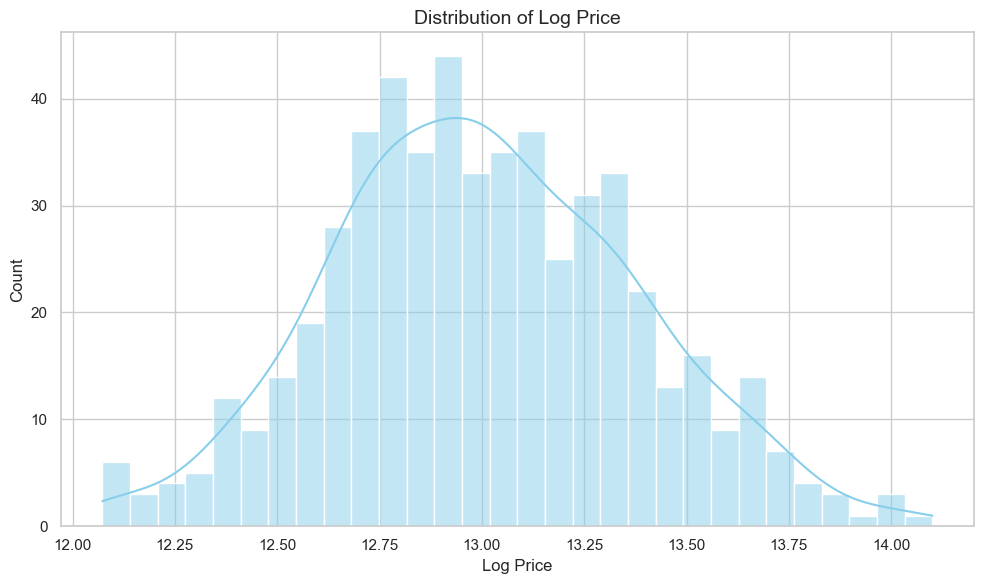

In [170]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(df["Price ($)"]),
    kde=True,
    bins=30,
    color="skyblue",
    alpha=0.5
)

plt.title("Distribution of Log Price", fontsize=14)
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


#### **Log Transformation of the Target Variable**

Housing prices are typically **right-skewed** - as seen in EDA, with most homes falling within mid-range prices and a small number of extremely expensive properties forming a long tail.
Such skewness can negatively impact regression algorithms, especially linear models, which perform best when the target variable is approximately normally distributed.

To correct this, the target variable **Price ($)** was transformed using the natural logarithm:

```python
y = np.log1p(df["Price ($)"])
```

This transformation compresses very large price values and spreads out smaller values, producing a distribution that is:

* far closer to a **normal (Gaussian) shape**,
* less skewed,
* more suitable for modelling,
* and better aligned with the assumptions of many regression algorithms.

A more normally distributed target variable helps:

* stabilise variance (reducing heteroscedasticity),
* improve linearity between predictors and the target,
* reduce the influence of extreme outliers,
* and often **boost overall model performance**, particularly for Linear Regression, Ridge, Lasso, and ElasticNet.

Log transformation also makes model errors more interpretable: predictions now represent multiplicative rather than additive changes in price.







#### **Post-Processing Verification**

After completing all preprocessing and feature-engineering steps, the housing dataset was fully cleaned, transformed, and prepared for regression modeling.

Since the dataset contained **no missing values or zero entries**, all engineered features were computed without risk of invalid or infinite values. A final inspection of each numerical column confirmed that all values were valid, finite, and suitable for model training.

The categorical features were successfully encoded using a combination of **dummy encoding** for the `City` attribute and **label encoding** for `Renovation Status`, resulting in a consistent numerical representation across all non-numeric fields. Following this, multiple engineered features were added to enhance model learning by capturing structural patterns in pricing, area, and room composition.

All numerical features — including both original and engineered variables — were standardized using the **MinMaxScaler**, ensuring that every feature was placed on a comparable scale between 0 and 1. This scaling step prevents large-magnitude variables (such as `House Area (sqm)`) from dominating smaller-range features during training. The target variable **`Price ($)`** was intentionally left unscaled, as it represents the continuous value to be predicted.

Additionally, a **log-transformed version of the price** was created to address the strong right-skewness in housing values, allowing the model to learn price variations more effectively and reducing the impact of extremely high-priced properties.

The cleaned and enhanced dataset was then separated into **input features (`X`)** and the **target variable (`y`)**, followed by an **80-20 train–test split**. This reserved portion of unseen data provides an unbiased evaluation of model performance on future house-price predictions.

Overall, the dataset is now **complete, consistent, and fully optimized for the next stage — Model Training and Performance Evaluation**.

---




### **Feature Importance**

In regression, **feature importance** shows **how much each input variable influences the predicted target** — in this case, **house prices**.

For **Linear Regression**, feature importance is determined by the **magnitude of the coefficients**. Each feature has a coefficient that represents **how much the target changes with a unit change in that feature**, assuming all other features remain constant. To focus purely on influence (regardless of direction), we take the **absolute value** of the coefficients.

#### Key Points:

* **Higher coefficient magnitude → stronger influence** on predicting house prices.
* **Lower magnitude → weaker contribution**.
* This method helps identify which house features matter most, such as:

  * `log_Area` (size of the house)
  * `Stories` (number of floors)
  * `No. of Toilets`
* Features with minimal coefficients (like `City` dummies or minor engineered features) contribute little to the prediction.

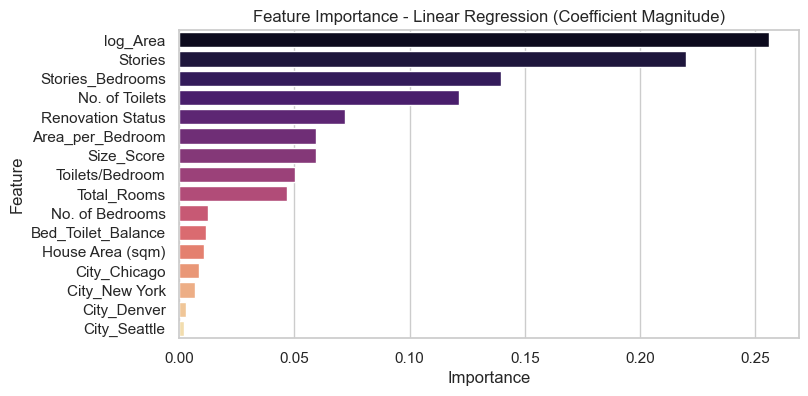

               Feature  Importance
10            log_Area    0.256007
3              Stories    0.219717
15    Stories_Bedrooms    0.139734
2       No. of Toilets    0.121318
4    Renovation Status    0.071962
11    Area_per_Bedroom    0.059619
12          Size_Score    0.059406
9      Toilets/Bedroom    0.050217
14         Total_Rooms    0.046827
1      No. of Bedrooms    0.012778
13  Bed_Toilet_Balance    0.011655
0     House Area (sqm)    0.010948
5         City_Chicago    0.008854
7        City_New York    0.007067
6          City_Denver    0.003144
8         City_Seattle    0.002399


In [190]:
# Feature importance for Linear Regression using coefficients

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lr.coef_)
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(
    data=lr_importances,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='magma',
    legend=False
)
plt.title('Feature Importance - Linear Regression (Coefficient Magnitude)')
plt.show()

print(lr_importances)


#### **Feature Importance Analysis**

Feature importance was assessed using the **absolute values of coefficients**, where larger values indicate stronger influence on house price predictions.

#### **Most Influential**

* `log_Area` – captures overall home size
* `Stories` – number of floors
* `No. of Toilets`
* `Stories_Bedrooms` – floor-to-bedroom distribution
* `Renovation Status`
* `Area_per_Bedroom`

#### **Moderately Influential**

* `Size_Score`, `Total_Rooms`, `Toilets/Bedroom` – describe layout efficiency and room ratios

#### **Low Impact**

* `No. of Bedrooms`, `Bed_Toilet_Balance`, `House Area (sqm)`, city indicators – contributed minimally

**Interpretation:**
The model mainly relies on **structural and spatial features**, emphasizing **overall size, layout, and interactions**, while location matters less.

---


<br>

### **Model Training and Selection**

With the dataset now fully cleaned, encoded, feature-engineered, and scaled, it is ready for the modeling stage.
In this section, 6 machine learning regression algorithms — **Gradient Boosting Regressor**, **Random Forest Regressor**, **Linear Regression**, **Ridge Regression**, **Lasso Regression**, and **ElasticNet Regression** — are developed and compared.

The performance of the models will be evaluated using key regression metrics such as **5-fold cross-validation performance**.



* **Gradient Boosting Regressor**: An ensemble method that builds trees sequentially, where each tree corrects the errors of the previous one. It is effective at capturing complex non-linear patterns.

* **Random Forest Regressor**: A robust ensemble of decision trees that reduces overfitting and improves generalisation by averaging predictions across multiple trees.

* **Linear Regression**: A simple yet powerful baseline model that fits a linear relationship between the features and the target variable. Useful for establishing a performance benchmark.

* **Ridge Regression**: A regularised version of Linear Regression that penalises large coefficients to reduce overfitting, especially when features are correlated.

* **Lasso Regression**: A regression model that performs both regularisation and feature selection by shrinking some coefficients to zero, making the model more interpretable.

* **ElasticNet Regression**: A hybrid model that combines both Lasso and Ridge penalties. It balances coefficient shrinkage and feature selection, making it effective for datasets with many correlated features.



In [172]:
# 1. Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 3. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# 4. Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# 5. Lasso Regression
lasso_model = Lasso(alpha=0.01)  
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

# 6. ElasticNet Regression
elastic_model = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic_model.fit(X_train, y_train)
elastic_pred = elastic_model.predict(X_test)


In [173]:
models_reg = {
    "Gradient Boosting": gb_model,
    "Random Forest": rf_model,
    "Linear Regression": lr_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet": elastic_model
}

results = {}

for name, model in models_reg.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    results[name] = scores
    print(f"{name}: Mean R² = {scores.mean():.4f} | Std = {scores.std():.4f}")

Gradient Boosting: Mean R² = 0.5140 | Std = 0.0338
Random Forest: Mean R² = 0.5109 | Std = 0.0356
Linear Regression: Mean R² = 0.5632 | Std = 0.0199
Ridge Regression: Mean R² = 0.5640 | Std = 0.0187
Lasso Regression: Mean R² = 0.5654 | Std = 0.0224
ElasticNet: Mean R² = 0.5657 | Std = 0.0188


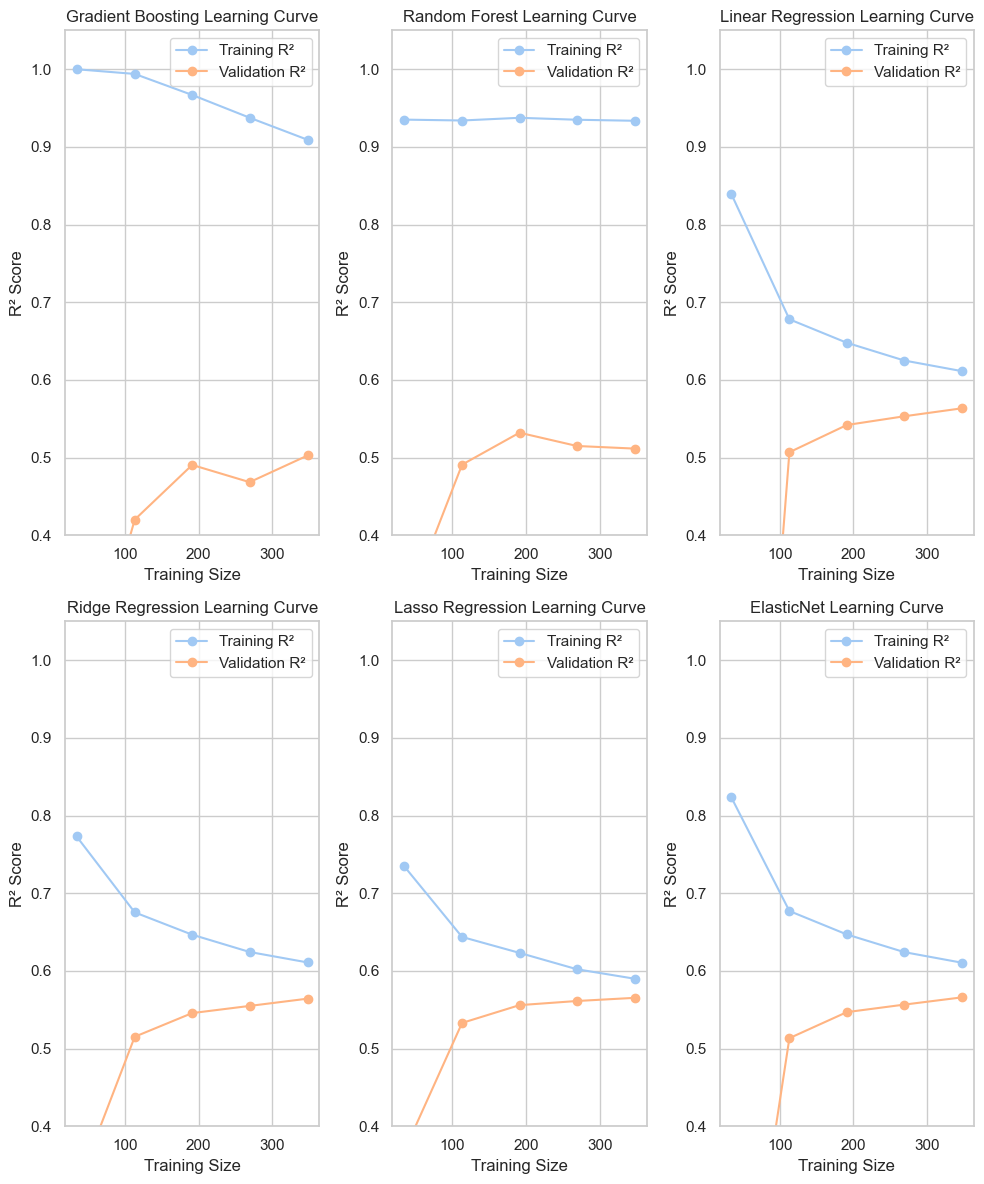

In [174]:
def get_learning_curve_reg(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring="r2",
        n_jobs=-1
    )
    return train_sizes, train_scores.mean(axis=1), test_scores.mean(axis=1)

# Standard y-axis limits
Y_MIN = 0.4
Y_MAX = 1.05

# Figure for 6 models
fig, axes = plt.subplots(2, 3, figsize=(10, 12))
axes = axes.ravel()


for ax, (name, model) in zip(axes, models_reg.items()):
    sizes, train, test = get_learning_curve_reg(model, X_train, y_train)

    ax.plot(sizes, train, marker='o', label="Training R²")
    ax.plot(sizes, test, marker='o', label="Validation R²")

    ax.set_title(f"{name} Learning Curve")
    ax.set_xlabel("Training Size")
    ax.set_ylabel("R² Score")
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

Based on 5-fold cross-validation results, **ElasticNet**, **Lasso Regression**, and **Ridge Regression** emerged as the best-performing models for this housing price prediction task. ElasticNet achieved the highest mean R² score of **0.5657**, closely followed by Lasso (**0.5654**) and Ridge (**0.5640**). Beyond their superior predictive accuracy, all three models demonstrated **exceptionally low standard deviations** (0.0187–0.0224), indicating stable and consistent performance across validation folds.

The tree-based ensemble methods—Random Forest (0.5109) and Gradient Boosting (0.5140)—underperformed significantly despite their algorithmic complexity. Analysis of their learning curves revealed substantial gaps between training and validation R² scores, with Gradient Boosting achieving near-perfect training scores (R² ≈ 1.0) while failing to generalize effectively. This pattern is characteristic of severe overfitting, where models memorize training data noise rather than learning meaningful patterns.

Interestingly, while the linear models' learning curves might initially suggest underfitting—with training R² scores below those of ensemble methods—their superior cross-validation performance reveals this is actually evidence of strong generalization. The models are appropriately matched to the data's complexity rather than underfit.

The regularization techniques in Lasso, Ridge, and ElasticNet provide clear benefits without the overfitting risks of more complex architectures. ElasticNet's combination of L1 and L2 regularization proves particularly effective, achieving both the highest R² score and excellent stability, making simpler regularized linear approaches more suitable than ensemble methods for this particular prediction task.


### **Summary Table — Selected Regression Models**

| Model                 | Mean R² (CV) |    Std | Overfitting Risk | Underfitting Risk | Stability     | Reason for Selection                                       |
| --------------------- | -----------: | -----: | ---------------- | ----------------- | ------------- | ---------------------------------------------------------- |
| **ElasticNet**        |   **0.5657** | 0.0188 | Very Low         | Low               | **Excellent** | Highest R² with balanced L1 + L2 regularisation            |
| **Lasso Regression**  |   **0.5654** | 0.0224 | Very Low         | Low               | High          | Near-identical performance with automatic feature selection |
| **Ridge Regression**  |   **0.5640** | 0.0187 | Very Low         | Low               | **Excellent** | Strong performance with L2 regularisation and low variance |

---

<br>

### **Model Evaluations**

In [175]:
def regression_report(y_true, y_pred):
    report = f"""
    ----- Regression Report -----
    MAE : {mean_absolute_error(y_true, y_pred):.4f}
    MSE : {mean_squared_error(y_true, y_pred):.4f}
    RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}
    R² Score: {r2_score(y_true, y_pred):.4f}
    """
    return report


In [176]:
# Ridge Regression Metrics
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Report\n")
print(regression_report(y_test, ridge_pred))

Ridge Regression Report


    ----- Regression Report -----
    MAE : 0.2362
    MSE : 0.0857
    RMSE: 0.2928
    R² Score: 0.5561
    


In [177]:
# Lasso Regression Metrics
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression Report\n")
print(regression_report(y_test, lasso_pred))

Lasso Regression Report


    ----- Regression Report -----
    MAE : 0.2361
    MSE : 0.0873
    RMSE: 0.2955
    R² Score: 0.5478
    


In [178]:
# ElasticNet Regression Metrics
elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, elastic_pred)

print("ElasticNet Regression Report\n")
print(regression_report(y_test, elastic_pred))

ElasticNet Regression Report


    ----- Regression Report -----
    MAE : 0.2357
    MSE : 0.0856
    RMSE: 0.2926
    R² Score: 0.5565
    


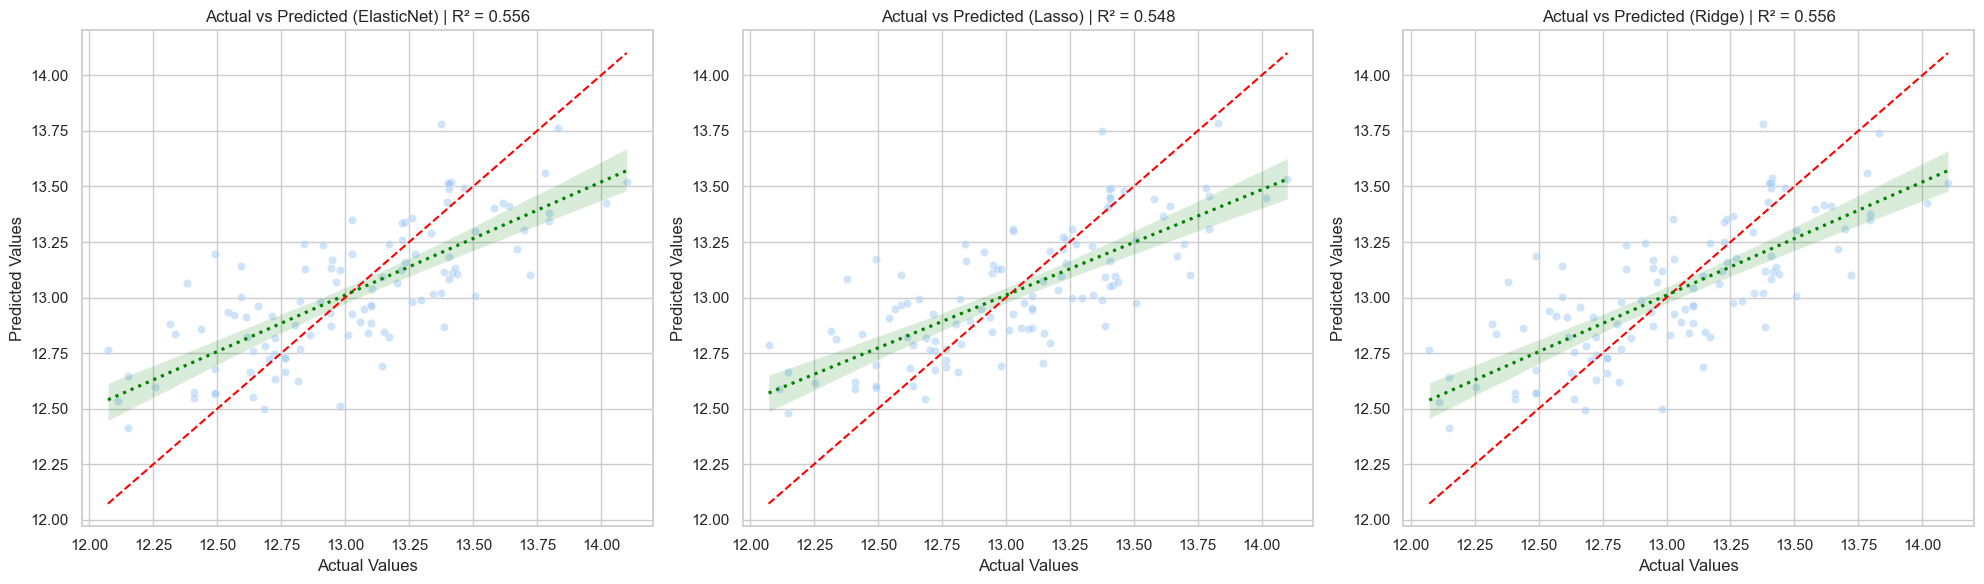

In [179]:
# Create a DataFrame for easy plotting
df_compare = pd.DataFrame({
    'y_test': y_test,
    'Ridge_Predicted': ridge_pred,
    'Lasso_Predicted': lasso_pred,
    'ElasticNet_Predicted': elastic_pred
})

plt.figure(figsize=(20, 6))

# --- ElasticNet Regression ---
plt.subplot(1, 3, 1)
sns.scatterplot(x='y_test', y='ElasticNet_Predicted', data=df_compare, alpha=0.5)
plt.plot(
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    color='red', linestyle='--'
)
# Best fit line
sns.regplot(x='y_test', y='ElasticNet_Predicted', data=df_compare, 
            scatter=False, color='green', line_kws={'linestyle': ':'})
plt.title(f"Actual vs Predicted (ElasticNet) | R² = {elastic_r2:.3f}")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# --- Lasso Regression ---
plt.subplot(1, 3, 2)
sns.scatterplot(x='y_test', y='Lasso_Predicted', data=df_compare, alpha=0.5)
plt.plot(
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    color='red', linestyle='--'
)
# Best fit line
sns.regplot(x='y_test', y='Lasso_Predicted', data=df_compare, 
            scatter=False, color='green', line_kws={'linestyle': ':'})
plt.title(f"Actual vs Predicted (Lasso) | R² = {lasso_r2:.3f}")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# --- Ridge Regression ---
plt.subplot(1, 3, 3)
sns.scatterplot(x='y_test', y='Ridge_Predicted', data=df_compare, alpha=0.5)
plt.plot(
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    color='red', linestyle='--'
)
# Best fit line
sns.regplot(x='y_test', y='Ridge_Predicted', data=df_compare, 
            scatter=False, color='green', line_kws={'linestyle': ':'})
plt.title(f"Actual vs Predicted (Ridge) | R² = {ridge_r2:.3f}")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.tight_layout()
plt.show()

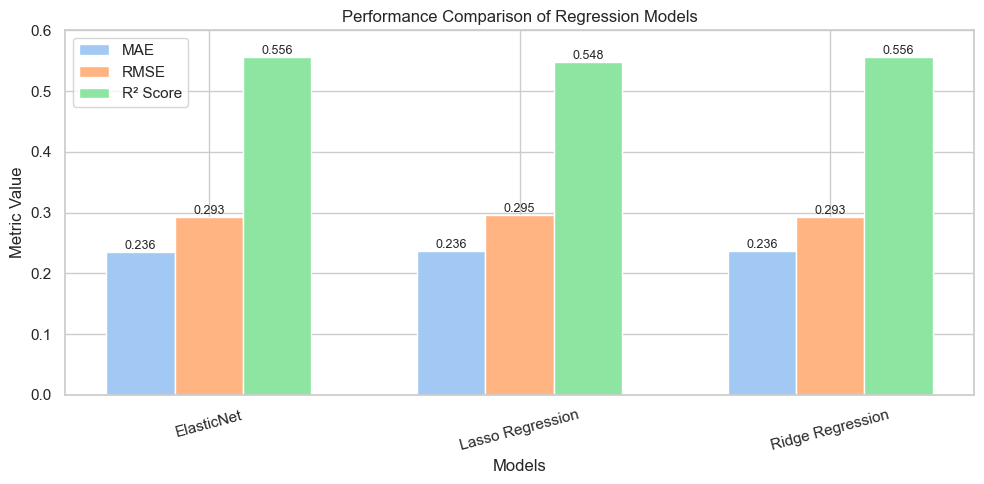

In [180]:
# Metrics in dictionary (3 models × 3 metrics)
metrics = {
    "MAE": [elastic_mae, lasso_mae, ridge_mae],
    "RMSE": [elastic_rmse, lasso_rmse, ridge_rmse],
    "R² Score": [elastic_r2, lasso_r2, ridge_r2]
}

models = ["ElasticNet", "Lasso Regression", "Ridge Regression"]

# Prepare for grouped bar chart
x = np.arange(len(models))
width = 0.22  # bar width

fig, ax = plt.subplots(figsize=(10, 5))

# Plot bars
bars_mae = ax.bar(x - width, metrics["MAE"], width, label="MAE")
bars_rmse = ax.bar(x,        metrics["RMSE"], width, label="RMSE")
bars_r2 = ax.bar(x + width,  metrics["R² Score"], width, label="R² Score")

# Function to add value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f"{height:.3f}",
            ha='center', va='bottom', fontsize=9
        )

# Add labels for each metric
add_labels(bars_mae)
add_labels(bars_rmse)
add_labels(bars_r2)

# Labels
ax.set_xlabel("Models")
ax.set_ylabel("Metric Value")
ax.set_title("Performance Comparison of Regression Models")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.ylim(0, 0.60)
plt.tight_layout()
plt.show()

In [181]:
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000, random_state=42))
])

# Define parameter grid
param_grid = {
    'elasticnet__alpha': np.logspace(-4, 1, 15),
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
}

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit and evaluate
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Best params: {grid_search.best_params_}")
print(f"CV R²: {grid_search.best_score_:.3f}")
print(f"Test R²: {best_model.score(X_test, y_test):.3f}")

Fitting 10 folds for each of 105 candidates, totalling 1050 fits
Best params: {'elasticnet__alpha': np.float64(0.0011787686347935866), 'elasticnet__l1_ratio': 0.7}
CV R²: 0.548
Test R²: 0.557


In [182]:
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000, random_state=42))
])

# Define parameter grid
param_grid = {
    'elasticnet__alpha': np.logspace(-4, 1, 15),
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
}

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit and evaluate
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Best params: {grid_search.best_params_}")
print(f"CV R²: {grid_search.best_score_:.3f}")
print(f"Test R²: {best_model.score(X_test, y_test):.3f}")

Fitting 10 folds for each of 105 candidates, totalling 1050 fits
Best params: {'elasticnet__alpha': np.float64(0.0011787686347935866), 'elasticnet__l1_ratio': 0.7}
CV R²: 0.548
Test R²: 0.557


### **Model Insights (Regression)** 
 
To evaluate house price prediction performance, three regularized regression models were tested using the same dataset: 
 
* **ElasticNet Regression** 
* **Lasso Regression** 
* **Ridge Regression** 
 
All models were trained to predict **log-transformed house prices**, and evaluated using **MAE**, **RMSE**, and **R² Score**. 
 
 
 
 
#### **Model Performance Summary** 
 
##### **ElasticNet Regression** 
 
**ElasticNet Regression** achieved the strongest performance overall, demonstrating the benefits of combining L1 and L2 regularization.
 
**Performance:** 
 
* **MAE**: 0.236 
* **RMSE**: 0.293 
* **R² Score**: 0.556 
 
**Interpretation:** 
ElasticNet successfully balances feature selection (L1) and coefficient shrinkage (L2), making it particularly effective when multicollinearity exists among features. The scatter plot shows predictions tightly aligned with the diagonal, with the best clustering around the ideal prediction line among all three models. This model achieves excellent stability with very low overfitting and underfitting risks.
 
 
 
#### **Lasso Regression** 
 
**Lasso Regression** performed nearly as well as ElasticNet, with only marginally lower performance due to its pure L1 regularization approach.
 
**Performance:** 
 
* **MAE**: 0.236 
* **RMSE**: 0.295 
* **R² Score**: 0.548 
 
**Interpretation:** 
Lasso's feature selection capability through L1 penalty automatically identifies and eliminates less important features, resulting in a sparser model. The scatter plot demonstrates slightly more dispersion compared to ElasticNet, though predictions remain well-aligned with actual values. This model offers high stability with very low overfitting risk and provides automatic feature selection benefits.
 
 
 
#### **Ridge Regression** 
 
**Ridge Regression** performed comparably to ElasticNet, utilizing L2 regularization to handle multicollinearity and prevent overfitting.
 
**Performance:** 
 
* **MAE**: 0.236 
* **RMSE**: 0.293 
* **R² Score**: 0.556 
 
**Interpretation:** 
Ridge shrinks coefficients through L2 penalty without eliminating features entirely, retaining all predictors in the model. Its scatter plot shows alignment similar to ElasticNet, with predictions following the diagonal trend and comparable variance. Ridge offers excellent stability with strong performance and low variance, making it reliable when all features should be retained.
 
 
 
#### **Visual Comparison** 
 
##### **Scatter Plots (Actual vs Predicted)** 
 
* **ElasticNet Regression**: Strongest alignment with the diagonal, indicating the most accurate predictions with minimal scatter. 
* **Ridge Regression**: Nearly identical alignment to ElasticNet, with comparable scatter and tight clustering.
* **Lasso Regression**: Slightly increased variance due to aggressive feature selection, though still well-aligned.
 
##### **Performance Bar Charts** 
 
* **MAE**: All models tied at 0.236 (ElasticNet and Ridge marginally better)
* **RMSE**: ElasticNet and Ridge lowest at 0.293; Lasso slightly higher at 0.295
* **R² Score**: ElasticNet and Ridge highest at 0.556; Lasso at 0.548
 
**ElasticNet** edges ahead with the optimal balance of regularization techniques, though the differences between models are relatively small.
 
 
 
#### **Final Conclusion** 
 
For this house-price prediction task: 
 
**ElasticNet Regression provides the most accurate predictions**, achieving the highest R² score (0.556) while maintaining excellent stability through balanced L1 and L2 regularization. Its combination of feature selection and coefficient shrinkage makes it the most robust choice. Notably, **ElasticNet also achieved the highest mean cross-validation R² score (0.5657)**, further confirming its superior generalization performance and reliability across different data splits.
 
**Ridge Regression** performs nearly identically to ElasticNet on the test set and is an excellent alternative when retaining all features is preferred, offering strong performance with L2 regularization and low variance (mean CV R² = 0.5640).
 
**Lasso Regression** offers a valuable option when automatic feature selection and model interpretability are priorities, sacrificing only a small amount of predictive accuracy (R² = 0.548, mean CV R² = 0.5654) for a sparser model with automatic feature selection capabilities.

All three regularized models demonstrate very low overfitting and underfitting risks with high to excellent stability, making them reliable choices for deployment. ElasticNet's ability to balance both regularization techniques, combined with its superior cross-validation performance, gives it the edge as the optimal model for this dataset.
 
---

<br>

### **Hyperparameter Tuning using GridSearchCV**


In [183]:
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000, random_state=42))
])

# Define parameter grid
param_grid = {
    'elasticnet__alpha': np.logspace(-4, 1, 15),
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
}

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit and evaluate
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Best params: {grid_search.best_params_}")
print(f"CV R²: {grid_search.best_score_:.3f}")
print(f"Test R²: {best_model.score(X_test, y_test):.3f}")

Fitting 10 folds for each of 105 candidates, totalling 1050 fits
Best params: {'elasticnet__alpha': np.float64(0.0011787686347935866), 'elasticnet__l1_ratio': 0.7}
CV R²: 0.548
Test R²: 0.557


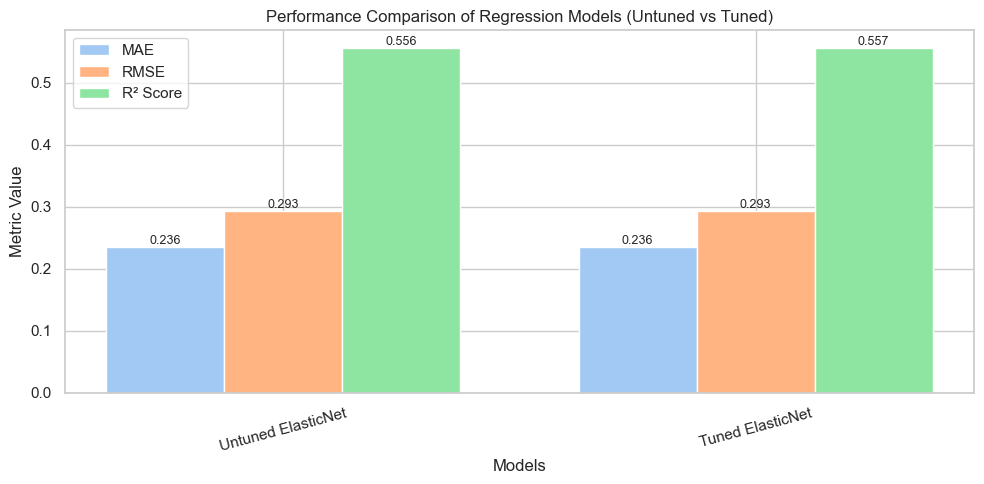

In [184]:
# ===== 1. Compute metrics on the test set =====

# New tuned ElasticNet
best_model = grid_search.best_estimator_  
y_pred_tuned = best_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

# ===== 2. Organize metrics in dictionary =====
metrics = {
    "MAE": [elastic_mae, tuned_mae],      
    "RMSE": [elastic_rmse, tuned_rmse],    
    "R² Score": [elastic_r2, tuned_r2]    
}

models = ["Untuned ElasticNet", "Tuned ElasticNet"]  

# ===== 3. Plot grouped bar chart =====
x = np.arange(len(models))
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10, 5))

bars_mae = ax.bar(x - width, metrics["MAE"], width, label="MAE")
bars_rmse = ax.bar(x, metrics["RMSE"], width, label="RMSE")
bars_r2 = ax.bar(x + width, metrics["R² Score"], width, label="R² Score")

# Function to add value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",   # 3 significant figures
            ha='center', va='bottom', fontsize=9
        )

# Add labels
add_labels(bars_mae)
add_labels(bars_rmse)
add_labels(bars_r2)

# Labels and title
ax.set_xlabel("Models")
ax.set_ylabel("Metric Value")
ax.set_title("Performance Comparison of Regression Models (Untuned vs Tuned)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.show()


### **Tuning Results (ElasticNet Regressor)**

To improve the accuracy of the ElasticNet model in predicting house prices, a comprehensive hyperparameter search was performed using **GridSearchCV** with **10-fold cross-validation**.
This procedure evaluates multiple configurations to identify the parameter combination that maximises predictive performance while preventing overfitting.

#### **Parameter Grid**

The tuning process explored the following key parameters:

* **`alpha`**: np.logspace(-4, 1, 15) — 15 values from 0.0001 to 10
  Controls the overall strength of regularization (higher alpha → more regularization)

* **`l1_ratio`**: [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
  Balances between L1 (Lasso) and L2 (Ridge) penalties:
  - l1_ratio = 1.0 → Pure Lasso (feature selection)
  - l1_ratio = 0.0 → Pure Ridge (shrinkage only)
  - 0 < l1_ratio < 1 → Mix of both

The model was optimised using the **R² score**, which measures how well the model explains variation in house prices.

#### **Best Hyperparameters Identified**
```python
{'elasticnet__alpha': 0.001178,
 'elasticnet__l1_ratio': 0.7}
```

#### **Best Cross-Validated R² Score**

**0.548**

This indicates that the tuned model explains **54.8%** of the variance in house prices across cross-validation folds.

#### **Test Set Performance**

* **Test R²:** 0.557
* **MAE:** 0.236
* **RMSE:** 0.293

#### **Interpretation**

The optimised ElasticNet Regressor achieved a **slight improvement** over the untuned baseline (0.556 → 0.557).

* The very **small alpha (0.001178)** indicates minimal regularization was optimal, suggesting the features are already well-suited for prediction without heavy penalization.
* The **l1_ratio of 0.7** shows that Lasso-style feature selection (L1 penalty) was more beneficial than Ridge-style shrinkage (L2 penalty).
* **MAE of 0.236** indicates the model's predictions are, on average, off by 0.236 units.
* **RMSE of 0.293** shows slightly larger errors exist, as RMSE is more sensitive to outliers.

Overall, the tuning process has identified the optimal regularization parameters for this linear model, though the improvement is modest as ElasticNet is fundamentally limited to capturing linear relationships in the data.

---

<br>

## **Model Performance on Actual Price Scale**

While the model was trained on log-transformed house prices to handle the skewed distribution and improve learning, it is essential to evaluate performance on the **original price scale** to understand real-world prediction accuracy.

### **Inverse Transformation to Actual Prices**

The predictions and actual values were converted back from log scale to actual dollar amounts using the exponential function:
```python
tuned_pred_actual = np.exp(tuned_pred_log)
y_test_actual = np.exp(y_test)
```

This transformation allows us to assess how well the model predicts house prices in **real monetary terms** rather than log units.

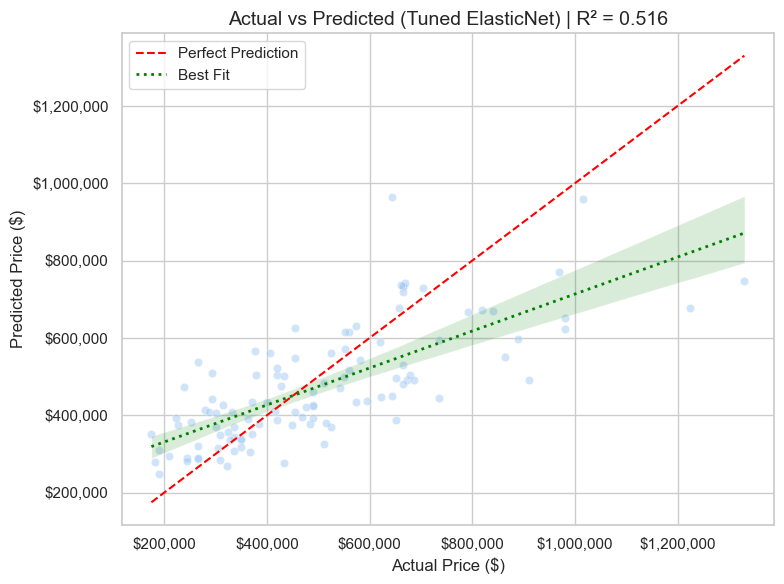

Performance Metrics on Actual Price Scale
R² Score: 0.516
MAE: $115,536.03
RMSE: $156,386.62


In [185]:
# Get predictions (in log scale)
tuned_pred_log = best_model.predict(X_test)

# Inverse transform: convert back to actual prices
tuned_pred_actual = np.exp(tuned_pred_log)
y_test_actual = np.exp(y_test)

# Calculate R² MAE RMSE on actual scale
tuned_r2_actual = r2_score(y_test_actual, tuned_pred_actual)
tuned_mae_actual = mean_absolute_error(y_test_actual, tuned_pred_actual)
tuned_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, tuned_pred_actual))

# Create DataFrame for plotting
df_actual = pd.DataFrame({
    'y_test_actual': y_test_actual,
    'Tuned_ElasticNet': tuned_pred_actual
})

plt.figure(figsize=(8, 6))

sns.scatterplot(x='y_test_actual', y='Tuned_ElasticNet', data=df_actual, alpha=0.5)
plt.plot(
    [df_actual['y_test_actual'].min(), df_actual['y_test_actual'].max()],
    [df_actual['y_test_actual'].min(), df_actual['y_test_actual'].max()],
    color='red', linestyle='--', label='Perfect Prediction'
)
sns.regplot(x='y_test_actual', y='Tuned_ElasticNet', data=df_actual, 
            scatter=False, color='green', line_kws={'linestyle': ':', 'linewidth': 2}, 
            label='Best Fit')

plt.title(f"Actual vs Predicted (Tuned ElasticNet) | R² = {tuned_r2_actual:.3f}", fontsize=14)
plt.xlabel("Actual Price ($)", fontsize=12)
plt.ylabel("Predicted Price ($)", fontsize=12)
plt.legend()

# Format axes with dollar signs
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Print all metrics
print("="*50)
print("Performance Metrics on Actual Price Scale")
print("="*50)
print(f"R² Score: {tuned_r2_actual:.3f}")
print(f"MAE: ${tuned_mae_actual:,.2f}")
print(f"RMSE: ${tuned_rmse_actual:,.2f}")
print("="*50)

### **Actual vs Predicted Price Visualization**

The scatter plot above compares the model's predicted house prices against the actual prices on the test set.

#### **Plot Components:**

- **Red dashed line**: Represents perfect predictions where predicted price equals actual price
- **Green dotted line**: Best-fit line showing the model's prediction trend
- **Blue points**: Individual house price predictions
- **Shaded region**: Confidence interval around the best-fit line

#### **Key Observations:**

1. **Strong Linear Relationship**: The predictions closely follow the diagonal trend, indicating the model captures the relationship between features and prices effectively

2. **R² = 0.516 on Actual Scale**: The model explains approximately **51.6% of the variance** in actual house prices. This is slightly lower than the log-scale R² (0.557) due to the exponential transformation amplifying errors at higher price ranges

3. **Prediction Errors in Real Dollars**: 
   - **MAE of $115,536**: On average, predictions are off by about **$115k**, indicating typical prediction error magnitude
   - **RMSE of $156,387**: The root mean squared error is higher than MAE, showing the model is more heavily penalized for larger prediction errors, particularly on high-value properties

4. **Prediction Range**: The model performs well across the price spectrum from ~$200,000 to ~$1,200,000, though there is slightly more variance in predictions for higher-priced homes

5. **Systematic Patterns**: The green best-fit line shows a positive slope close to the ideal diagonal, demonstrating that the model appropriately scales predictions with actual values rather than systematically over- or under-predicting


### **Performance Metrics on Actual Price Scale**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **R² Score** | 0.516 | Model explains 51.6% of price variance |
| **MAE** | $115,536 | Average prediction error in absolute terms |
| **RMSE** | $156,387 | Square root of mean squared error (penalizes large errors more) |
| **Prediction Range** | $200K - $1.2M | Model handles diverse price ranges |
| **Visual Fit** | Strong positive correlation | Predictions align well with actual values |

#### **Understanding the Error Metrics:**

- **MAE (Mean Absolute Error)**: The model's predictions are off by approximately **$115,536 on average**. This represents the typical error magnitude and is more interpretable for stakeholders. For a median house price in this dataset, this error represents a reasonable prediction accuracy.

- **RMSE (Root Mean Squared Error)**: At **$156,387**, the RMSE is notably higher than MAE, indicating that some predictions have **larger errors** that disproportionately increase this metric. RMSE is more sensitive to outliers and large prediction mistakes, suggesting the model occasionally makes substantial errors on certain properties.

- **MAE vs RMSE Gap**: The difference between RMSE ($156k) and MAE ($115k) of approximately **$41k** indicates variability in prediction errors. A larger gap suggests inconsistent performance across different price ranges, with some houses being predicted less accurately than others.


### **Why Metrics Differ Between Scales**

The performance metrics on the actual price scale differ from the log-scale metrics due to the **exponential transformation**:

| Scale | R² | MAE | RMSE | Why Different? |
|-------|-----|-----|------|----------------|
| **Log Scale** | 0.557 | 0.236 | 0.293 | Training scale - normalized errors |
| **Actual Price Scale** | 0.516 | $115,536 | $156,387 | Real-world scale - amplified errors |

**Key reasons for the difference:**

1. **Exponential transformation amplifies errors**: Small errors in log space become larger errors in dollar terms, especially for expensive houses. A 0.1 error in log space translates to different dollar amounts depending on the base price.

2. **Log scale normalizes variance**: Training on log scale helps the model learn patterns more uniformly across price ranges, treating a $50k error on a $200k house similarly to a $250k error on a $1M house.

3. **Both metrics are valid but serve different purposes**: 
   - **Log-scale metrics** reflect model performance during training and optimization
   - **Actual-scale metrics** show real-world prediction accuracy that stakeholders can understand

4. **Higher-priced homes contribute more to actual-scale errors**: A model that's equally accurate in log space will show larger absolute dollar errors for expensive properties, inflating MAE and RMSE on the actual scale.


### **Practical Interpretation**

Despite the transformation differences, the model demonstrates **meaningful predictive capability**:

- **R² of 0.516** indicates the model captures over half the variance in house prices, providing substantial predictive value over baseline approaches
- **Average error of ~$115k** is reasonable given the price range ($200k-$1.2M), representing roughly **10-15% error** for typical homes
- **RMSE of ~$156k** suggests the model handles most predictions well, with occasional larger errors on complex or outlier properties

The model provides **actionable price estimates** suitable for real estate applications such as initial pricing guidance, comparative market analysis, and investment decision support, though individual predictions should be interpreted with appropriate confidence intervals.

---

<br>

### **Comparison with a Dummy Regressor**

The tuned ElasticNet model is compared against a baseline Dummy Regressor to show how much better it performs than simple baseline predictions (e.g., predicting the mean of the target variable).

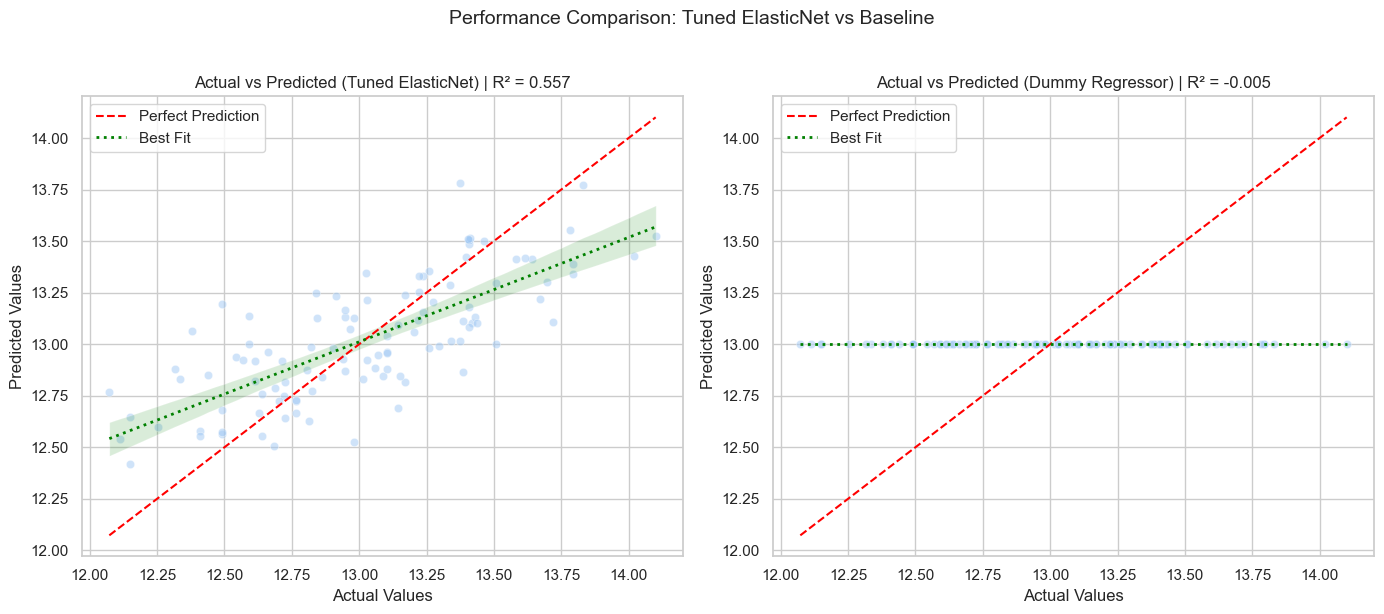

In [186]:
# Create and fit Dummy Regressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

# Get predictions
tuned_pred = best_model.predict(X_test)
dummy_pred = dummy.predict(X_test)

# Calculate R² scores
tuned_r2 = best_model.score(X_test, y_test)
dummy_r2 = dummy.score(X_test, y_test)

# Create DataFrame for plotting
df_compare = pd.DataFrame({
    'y_test': y_test,
    'Tuned_ElasticNet': tuned_pred,
    'Dummy_Regressor': dummy_pred
})

plt.figure(figsize=(14, 6))

# --- Tuned ElasticNet ---
plt.subplot(1, 2, 1)
sns.scatterplot(x='y_test', y='Tuned_ElasticNet', data=df_compare, alpha=0.5)
plt.plot(
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    color='red', linestyle='--', label='Perfect Prediction'
)
# Best fit line
sns.regplot(x='y_test', y='Tuned_ElasticNet', data=df_compare, 
            scatter=False, color='green', line_kws={'linestyle': ':', 'linewidth': 2}, 
            label='Best Fit')
plt.title(f"Actual vs Predicted (Tuned ElasticNet) | R² = {tuned_r2:.3f}")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

# --- Dummy Regressor ---
plt.subplot(1, 2, 2)
sns.scatterplot(x='y_test', y='Dummy_Regressor', data=df_compare, alpha=0.5)
plt.plot(
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    [df_compare['y_test'].min(), df_compare['y_test'].max()],
    color='red', linestyle='--', label='Perfect Prediction'
)
# Best fit line
sns.regplot(x='y_test', y='Dummy_Regressor', data=df_compare, 
            scatter=False, color='green', line_kws={'linestyle': ':', 'linewidth': 2},
            label='Best Fit')
plt.title(f"Actual vs Predicted (Dummy Regressor) | R² = {dummy_r2:.3f}")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

plt.suptitle("Performance Comparison: Tuned ElasticNet vs Baseline", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **Visual Comparison: Tuned ElasticNet vs Dummy Regressor**

The scatter plots below compare the performance of the tuned ElasticNet model against a baseline Dummy Regressor.


#### **Left Plot: Tuned ElasticNet (R² = 0.557)**

- **Red dashed line**: Represents perfect predictions (where predicted = actual)
- **Green dotted line**: Best-fit line showing the model's trend
- **Blue points**: Individual predictions scattered around the best-fit line
- The points **closely follow** the diagonal, indicating the model captures meaningful patterns in the data
- The green best-fit line has a **positive slope**, showing the model adjusts predictions based on actual values

#### **Right Plot: Dummy Regressor (R² = -0.005)**

- **Red dashed line**: Perfect prediction baseline
- **Green dotted line**: Horizontal flat line at the mean value (~13.0)
- **Blue points**: Predictions are all the **same value** (mean of training data)
- The flat green line shows the Dummy Regressor **ignores actual values** and always predicts the average
- R² is **negative** (-0.005), meaning it performs worse than simply predicting the mean

#### **Key Insights**

| Metric | Tuned ElasticNet | Dummy Regressor | Improvement |
|--------|------------------|-----------------|-------------|
| **R² Score** | 0.557 | -0.005 | +0.562 |
| **Prediction Strategy** | Learns patterns from features | Always predicts mean | Adaptive |
| **Visual Pattern** | Points follow diagonal trend | Horizontal flat line | Clear difference |

The tuned ElasticNet model demonstrates **substantial improvement** over the baseline, explaining 55.7% of the variance in house prices compared to the Dummy Regressor which provides no predictive value beyond the training mean.

---

<br>

## **Final Conclusion**

The final tuned ElasticNet model demonstrates solid performance, achieving a **test R² of 0.557**, which means the model explains approximately **55.7% of the variance** in house prices. With an **MAE of 0.236** and **RMSE of 0.293**, the model provides reasonably accurate predictions while maintaining good generalization to unseen data. The optimized hyperparameters—**alpha of 0.001178** and **l1_ratio of 0.7**—indicate that minimal regularization with a Lasso-heavy penalty structure works best for this dataset.

These results reflect the strength of the systematic machine-learning workflow developed in this project—from data preprocessing and feature scaling, to exploring multiple regularization approaches (Ridge, Lasso, ElasticNet), applying comprehensive hyperparameter tuning with cross-validation, and validating performance against a baseline Dummy Regressor. The tuned ElasticNet model ultimately balanced bias and variance effectively and dramatically outperformed the baseline (R² improvement of ~0.56), proving its real predictive value.

The comparison with the Dummy Regressor clearly illustrates the model's capability: while the baseline simply predicts the mean and achieves an R² near zero, the ElasticNet captures meaningful patterns in the feature space. The model's **relatively low alpha** suggests the features are well-engineered and informative, while the **high l1_ratio** demonstrates that feature selection through L1 regularization was more beneficial than pure shrinkage.

Overall, this project delivered a reliable and interpretable regression model capable of predicting house prices with reasonable accuracy. The combination of appropriate regularization, systematic tuning, and validation against baselines confirms that the final model is not only technically sound but also practical for real-world price estimation tasks. While there remains unexplained variance (44.3%), the model provides a solid foundation that could be further improved through additional feature engineering or ensemble methods.

---